# Example training

Requires the run of 2_train_test_splits

## 1. Preparations of the data

In [1]:
from pathlib import Path

artefacts_path = Path("..") / "data" /  "mini_dataset_artifact"
dataset_path = Path("..") / "data" / "mini_dataset"
split_to_use = "ea15dc911b89efb03435a87e27cb6e0bde336c0071a8c1b74c242d6774c7daeb"

In [2]:
import pandas as pd
from lit_ecology_classifier.splitting.split_processor import SplitProcessor

split_processor = SplitProcessor(artefacts_folder= artefacts_path, split_hash= split_to_use)
split_df = split_processor.get_split_df()
split_df.head()


INFO:lit_ecology_classifier.splitting.split_processor:Reloading split based on hash value: ea15dc911b89efb03435a87e27cb6e0bde336c0071a8c1b74c242d6774c7daeb
INFO:lit_ecology_classifier.splitting.split_processor:Path to used split: ../data/mini_dataset_artifact/splits/ea15dc911b89efb03435a87e.csv


,image,class,sha256,date,version_mini,image_path,class_map,split
0,SPC-EAWAG-0P5X-1591646991657195-12392367470731...,aphanizomenon,8193d264dd6fdeb40234471720ae359cdbb8634c8836e6...,2020-06-08 20:09:51+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,val
1,SPC-EAWAG-0P5X-1591628470416286-12373846494770...,aphanizomenon,650b97daf897675b5a2daa085cfb3b2c191148d80e9e9d...,2020-06-08 15:01:10+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train
2,SPC-EAWAG-0P5X-1656774336043045-61281211853089...,aphanizomenon,d207cd30c406d352aabac6073bea40d1477a18972e8cff...,2022-07-02 15:05:36+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train
3,SPC-EAWAG-0P5X-1591610837289696-12356213628703...,aphanizomenon,14bdb4fb957cf02d1ef4a14955f2f3904d42bc1b42af01...,2020-06-08 10:07:17+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train
4,SPC-EAWAG-0P5X-1656766937511689-61273813411030...,aphanizomenon,3279765c63868f36b999e4eb6ca7de31795e0ad18f66de...,2022-07-02 13:02:17+00:00,True,../data/mini_dataset/aphanizomenon/SPC-EAWAG-0...,0,train


In [3]:
class_map = split_processor.get_class_map()
class_map   

{'aphanizomenon': 0,
 'unknown': 4,
 'dinobryon': 1,
 'keratella_quadrata': 2,
 'polyarthra': 3}

## 2. Training the model

THe model training is based on the [Pytorch Lightning](https://pytorch-lightning.readthedocs.io/en/latest/) framework. It is a high-level interface for Pytorch that makes it easier to train models on multiple GPUs or Clusters.

### 2.1 LightningDataModule and DataLoaders

Native pytorch dataloaders are used to load the images and labels for the training. The LightningDataModule orchestrates the correct loading of the data and the creation of the dataloaders for training and validation on multiple GPUs.


In [4]:
from lit_ecology_classifier.data.datamodule import DataModule
import logging
from lightning.pytorch.loggers import CSVLogger

train_out = Path("..") / "train_out"
logger = CSVLogger(save_dir= train_out, name='csv_logs')

datamodule = DataModule(
        datapath= dataset_path,
        dataset = "mini_example",
        batch_size= 32,
        splits= split_df,
        augmentation_level = "low",
        resize_with_proportions = False,
        target_size = 224,

)

datamodule.setup()

INFO:root: Extracting class map from tar file.
INFO:lit_ecology_classifier.helpers.helpers:Extracting class map.
INFO:lit_ecology_classifier.helpers.helpers:Detected directory.
INFO:lit_ecology_classifier.helpers.helpers:Found 5 classes.
INFO:root:Class map: {'aphanizomenon': 0, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3, 'unknown': 4}
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 4988
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 831
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 832


### 2.2 Initialize the Model

In [5]:
from lit_ecology_classifier.models.model import LitClassifier

param_path = Path("..") / "params"

model = LitClassifier(
    train_outpath=train_out,     # Output path for training artifacts (models, metrics, ...)
    main_param_path=param_path,  # "Main directory where the training parameters are stored"
    class_map = class_map,
    use_wandb=False,             # Use Weights and Biases for logging
    no_use_multi=False,          # Use multiple GPUs for training
    architecture='mobilenetv3s', # Choose the model architecture (see options in model_mapping dictionary, in ../lit_ecology_classifier/models/setup_model.py)
    add_layer=False,             # Add additional layers to the model
    finetune=False,              # if True, only train the head of the network
    batch_size=128,              # Batch size for training
    lr=1e-5,                     # Learning rate for training
    lr_factor=0.01,              # Learning rate factor for training of full body
    loss="cross_entropy",        # Loss function ["cross_entropy", "focal"]
    testing=False,               # Set this to True if in testing mode, False for training
    no_TTA=False                 # Test-time augmentation - only for predict stage, 
)

model.load_datamodule(datamodule)


INFO:lit_ecology_classifier.models.setup_model:Preparing the model using a cached backbone or downloading from huggingface.
INFO:root:Model initialized with hyperparameters:
 {'add_layer': False,
 'architecture': 'mobilenetv3s',
 'batch_size': 128,
 'class_map': {'aphanizomenon': 0,
               'dinobryon': 1,
               'keratella_quadrata': 2,
               'polyarthra': 3,
               'unknown': 4},
 'finetune': False,
 'loss': 'cross_entropy',
 'lr': 1e-05,
 'lr_factor': 0.01,
 'main_param_path': PosixPath('../params'),
 'no_TTA': False,
 'no_use_multi': False,
 'num_classes': 5,
 'testing': False,
 'train_outpath': PosixPath('../train_out'),
 'use_wandb': False}


### 2.3 Pytorch Lightning Trainer


In [6]:
import os

import torch
import lightning as l
import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor


max_epochs = 15


accelerator = "gpu" if torch.cuda.device_count() else "cpu"
devices = torch.cuda.device_count() if "gpu" in accelerator else os.cpu_count() // 4
strategy ="ddp_notebook" if torch.cuda.device_count() > 1 else "auto"

defined_callbacks = [
    pl.callbacks.ModelCheckpoint(filename="best_model_acc_stage1", monitor="val_acc", mode="max"),
    LearningRateMonitor(logging_interval='step')
    ]


/home/marco/miniconda3/envs/jp2/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [7]:
trainer = l.Trainer(
        accelerator= accelerator,
        devices=1,
        logger=logger,
        max_epochs= max_epochs,
        log_every_n_steps=40,
        callbacks=[pl.callbacks.ModelCheckpoint(filename="best_model_acc_stage1", monitor="val_acc", mode="max"),LearningRateMonitor(logging_interval='step')],
        check_val_every_n_epoch=max(max_epochs // 8,1),
        strategy= strategy,
        default_root_dir=train_out,
    )


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### 2.4 Train the model

INFO:lit_ecology_classifier.data.datamodule:Train size of df: 4988
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 831
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 832

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | MobileNetV3      | 1.0 M  | train
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.088     Total estimated model params size (MB)
236       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

{'aphanizomenon': 0, 'unknown': 4, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3}
{0: 'aphanizomenon', 1: 'dinobryon', 2: 'keratella_quadrata', 3: 'polyarthra', 4: 'unknown'}


/media/marco/dropbox-2Tb/Dropbox/LAVORO/PROJECTS/AQUASCOPE/PROVE-JUAN/lit_ecology_classifier/notebooks/lit_ecology_classifier/helpers/modelling_plots.py:118: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  y_axis.set_yscale("log")
/home/marco/miniconda3/envs/jp2/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/marco/miniconda3/envs/jp2/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Training: |                                                                                                   …

...

{'aphanizomenon': 0, 'unknown': 4, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3}
{0: 'aphanizomenon', 1: 'dinobryon', 2: 'keratella_quadrata', 3: 'polyarthra', 4: 'unknown'}


/home/marco/miniconda3/envs/jp2/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Validation: |                                                                                                 …

{'aphanizomenon': 0, 'unknown': 4, 'dinobryon': 1, 'keratella_quadrata': 2, 'polyarthra': 3}
{0: 'aphanizomenon', 1: 'dinobryon', 2: 'keratella_quadrata', 3: 'polyarthra', 4: 'unknown'}


`Trainer.fit` stopped: `max_epochs=15` reached.


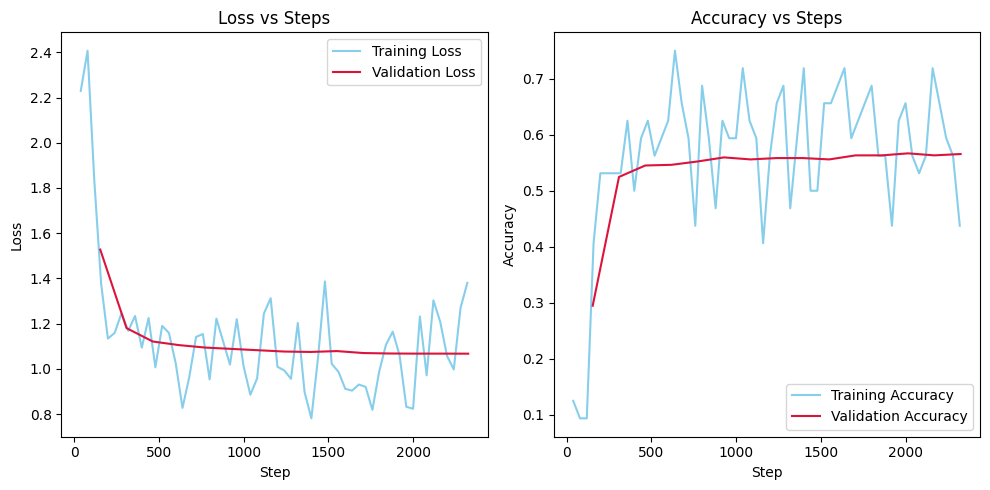

In [8]:
# try:
#     %load_ext autotime
# except:
#     !pip install ipython-autotime
#     %load_ext autotime

trainer.fit(model, datamodule=datamodule)

In [9]:
trainer.test()

/home/marco/miniconda3/envs/jp2/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:145: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
INFO:lit_ecology_classifier.data.datamodule:Train size of df: 4988
INFO:lit_ecology_classifier.data.datamodule:Validation size of df: 831
INFO:lit_ecology_classifier.data.datamodule:Test size of df: 832
Restoring states from the checkpoint path at ../train_out/csv_logs/version_3/checkpoints/best_model_acc_stage1.ckpt
Loaded model weights from the checkpoint at ../train_out/csv_logs/version_3/checkpoints/best_model_acc_stage1.ckpt


MisconfigurationException: `test_dataloader` must be implemented to be used with the Lightning Trainer